In [51]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [15]:
df = pd.read_csv('/home/phrenico/Projects/Codes/maco_commondriver/scripts_and_results/comparisons/unified_results/unified_results.csv', index_col=0)
cols = list(df.columns)

df.head(), cols

(   data_id         r method       dataset
 0        0  0.700734    ICA  logmap_fixed
 1        1  0.702184    ICA  logmap_fixed
 2        2  0.711358    ICA  logmap_fixed
 3        3  0.692003    ICA  logmap_fixed
 4        4  0.577562    ICA  logmap_fixed,
 ['data_id', 'r', 'method', 'dataset'])

In [17]:
df.dataset.unique()

array(['logmap_fixed', 'tentmap', 'lorenz'], dtype=object)

In [104]:
# apply multiple functions to the r column
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)
#
df_filtered = df[(df.dataset == 'logmap_fixed') | (df.dataset == 'tentmap')]
means = df_filtered.sort_values(by='method', ascending=True, inplace=False).groupby(['dataset', 'method'])['r'].agg(['mean', 'std', 'median', iqr]).reset_index()
display(means)

means.to_csv('/home/phrenico/Projects/Codes/maco_commondriver/scripts_and_results/comparisons/ToSoma/means.csv')

,dataset,method,mean,std,median,iqr
0,logmap_fixed,ASOM,0.808106,0.079965,0.820968,0.077848
1,logmap_fixed,CCA,0.720175,0.065250,0.732416,0.070552
2,logmap_fixed,DCA,0.703885,0.084769,0.704572,0.084398
3,logmap_fixed,DCCA,0.806933,0.078719,0.803747,0.119760
4,logmap_fixed,ICA,0.691560,0.077043,0.688938,0.078262
5,logmap_fixed,MaCo,0.954622,0.069617,0.972705,0.009818
6,logmap_fixed,PCA,0.693297,0.097145,0.712638,0.112133
7,logmap_fixed,Random,0.033929,0.006681,0.035304,0.003632
8,logmap_fixed,SFA,0.079273,0.043401,0.070054,0.069648
9,logmap_fixed,ShRec,0.728459,0.087839,0.725036,0.105213


In [57]:
# order the values in ascending order (correlation) ommit MaCo from the end
tent_map_order = means[means.dataset=='tentmap'].sort_values(by='median', ascending=True, inplace=False).method.values[:-1]
log_map_order = means[means.dataset=='logmap_fixed'].sort_values(by='mean', ascending=True, inplace=False).method.values[:-1]

In [43]:
datasets = df.dataset.unique()
for dataset in datasets:
    print(dataset)
    print(sorted(df[(df.dataset == dataset)].method.unique()))

logmap_fixed
['ASOM', 'CCA', 'DCA', 'DCCA', 'ICA', 'MaCo', 'PCA', 'Random', 'SFA', 'ShRec']
tentmap
['ASOM', 'CCA', 'DCA', 'DCCA', 'ICA', 'MaCo', 'PCA', 'Random', 'SFA', 'ShRec']
lorenz
['CCA', 'DCA', 'DCCA', 'ICA', 'MaCo', 'PCA', 'Random', 'SFA', 'ShRec']


## Create Figures without Maco

### Tentmap Figure

In [100]:
import seaborn as sns
sns.set(style="whitegrid")

def boxplot(asomdf, dataset, order, dpi=300):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(x='method', y='r', data=asomdf[asomdf.dataset==dataset], order=order,
                color='Red', ax=ax, showfliers=False)
    sns.stripplot(x='method', y='r', data=asomdf[asomdf.dataset==dataset], order=order,
                color='0.25', ax=ax, size=3)

    ax.set_ylim(0, 1)
    ax.set_xlabel('')
    ax.set_ylabel(r'Abs. Pearson Correlation $|r|$')

    fig.tight_layout(rect=[0, 0, 1, 1])
    fig.savefig(f'/home/phrenico/Projects/Codes/maco_commondriver/scripts_and_results/comparisons/ToSoma/{dataset}_correlation.png')

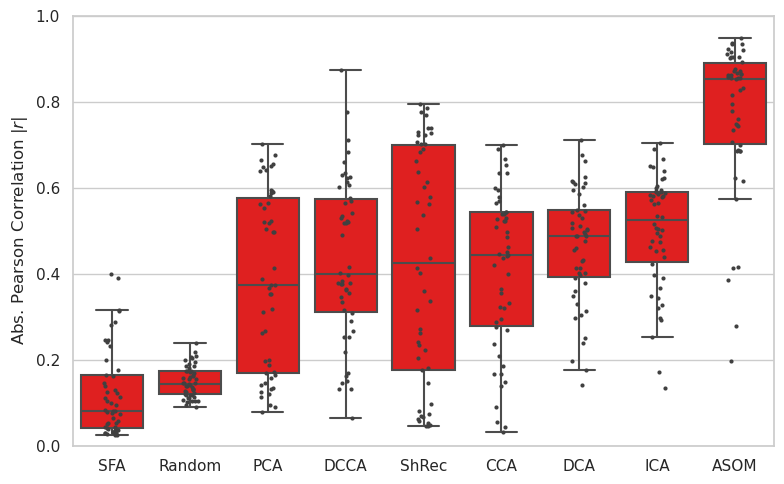

In [101]:
asomdf = df[df.method != 'MaCo']

boxplot(asomdf, 'tentmap', tent_map_order)

### logmap Figure

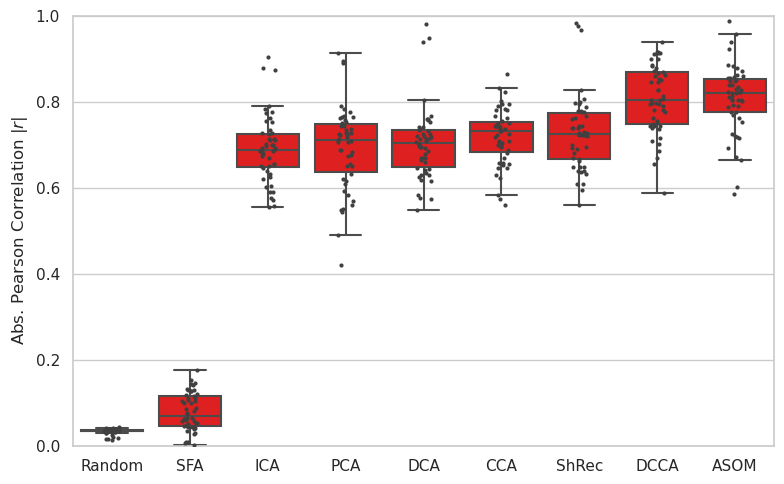

In [102]:
boxplot(asomdf, 'logmap_fixed', log_map_order)

<Axes: xlabel='method', ylabel='r'>

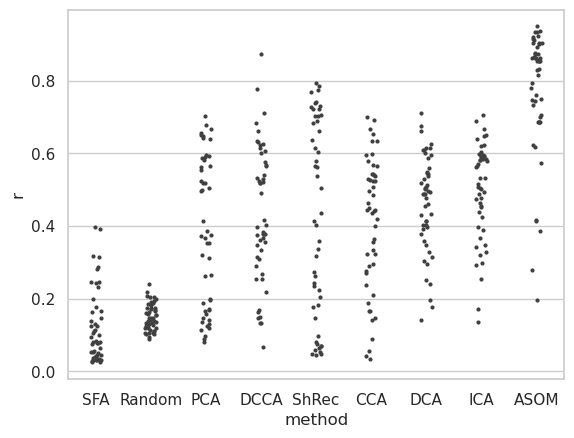

In [103]:
sns.stripplot(x='method', y='r', data=asomdf[asomdf.dataset=='tentmap'], order=tent_map_order, jitter=True, color='0.25', size=3)